In [1]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we run from project root so `data/raw` resolves correctly
if Path.cwd().name == "research":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

CWD: c:\Users\reymo\quant-portfolio


In [2]:
from src.analytics.hrp_optimizer import HrpOptimizer
from src.data.data_manager import DataManager

start_date = "2019-01-01"
end_date = "2023-12-31"

dm = DataManager(base_dir="data/raw")

tickers = dm.list_existing_tickers()

returns = dm.load_returns(tickers=tickers, start_date=start_date, end_date=end_date)

returns.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
AAPL,1033.0,0.001154,0.020858,-0.128647,-0.008785,0.000444,0.012396,0.119808
ABBV,1033.0,0.000826,0.015556,-0.130022,-0.006805,0.000674,0.008378,0.087174
ADBE,1033.0,0.000862,0.024492,-0.167932,-0.010567,0.000840,0.014097,0.177193
AIR.PA,1033.0,0.000472,0.028274,-0.221685,-0.011183,0.000758,0.011823,0.204633
AMZN,1033.0,0.000729,0.023417,-0.140494,-0.011653,0.000193,0.012793,0.135359


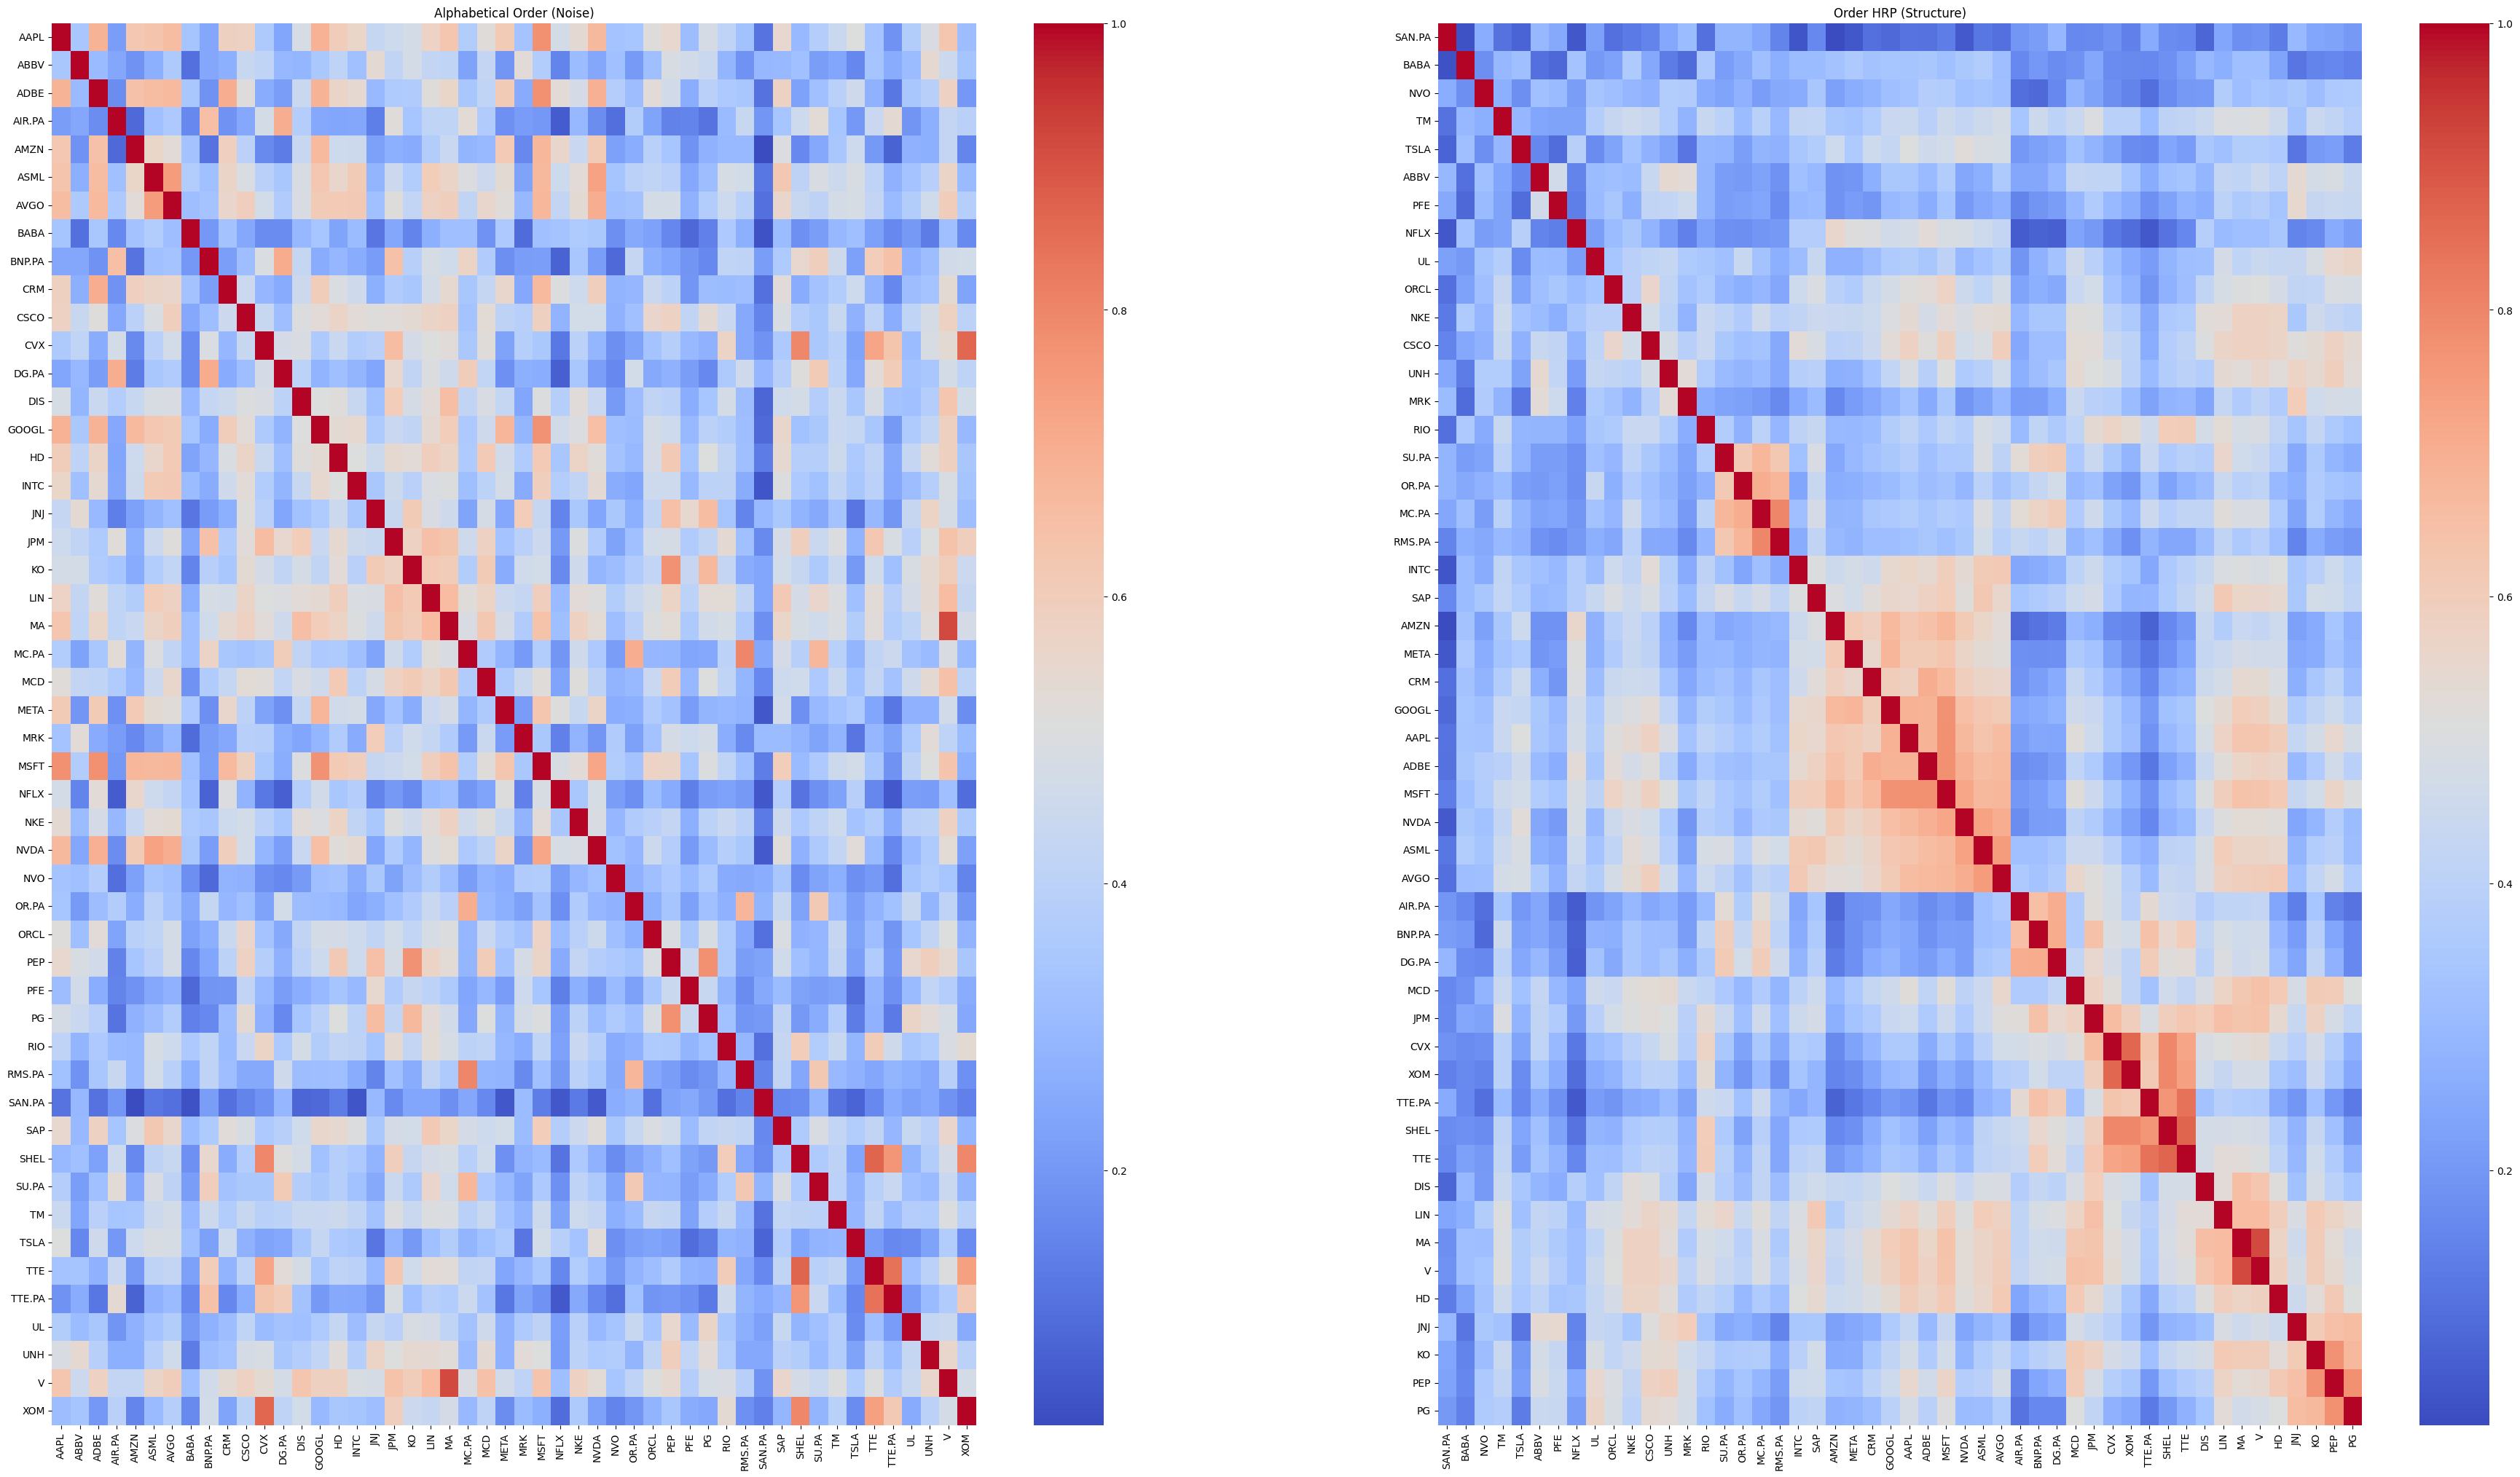

In [3]:
hrp = HrpOptimizer(returns)
sorted_list = hrp.get_sorted_tickers()

fig, ax = plt.subplots(1, 2, figsize=(45, 25))

sns.heatmap(returns.corr(), ax=ax[0], cmap="coolwarm")
ax[0].set_title("Alphabetical Order (Noise)")

sns.heatmap(returns[sorted_list].corr(), ax=ax[1], cmap="coolwarm")
ax[1].set_title("Order HRP (Structure)")

plt.show()

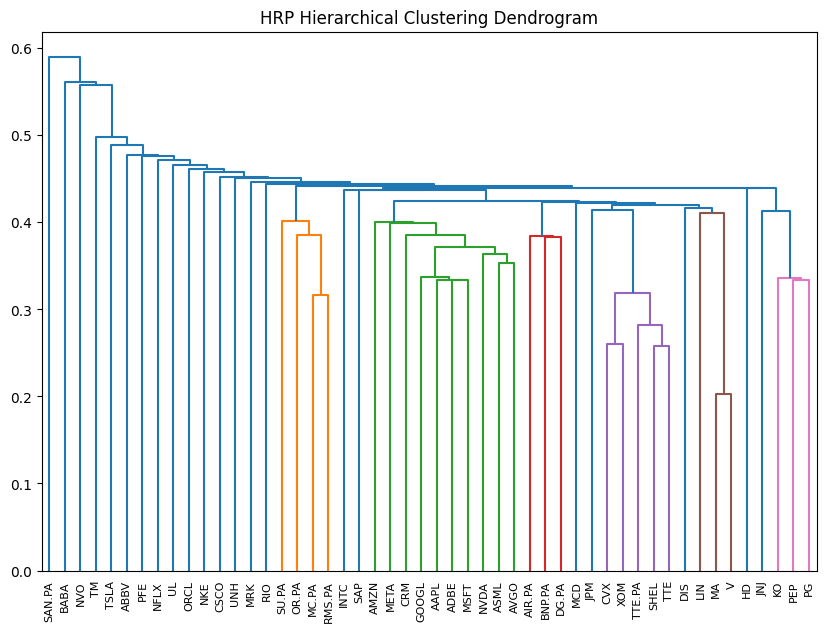

In [4]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sch.dendrogram(hrp.linkage_matrix, labels=hrp.tickers, leaf_rotation=90)
plt.title("HRP Hierarchical Clustering Dendrogram")
plt.show()

In [5]:
Sigma = returns.cov()
Sigma_ann = Sigma * 252
sorted_indices = hrp.get_quasi_diag()
weights = hrp.get_rec_bisection(Sigma_ann, sorted_indices=sorted_indices)
weights

SAN.PA    0.056928
BABA      0.010670
NVO       0.032428
TM        0.048516
TSLA      0.006167
ABBV      0.045638
PFE       0.034569
NFLX      0.010023
UL        0.039384
ORCL      0.021812
NKE       0.012879
CSCO      0.019046
UNH       0.029823
MRK       0.038528
RIO       0.017821
SU.PA     0.027846
OR.PA     0.023309
MC.PA     0.016224
RMS.PA    0.028643
INTC      0.009623
SAP       0.016064
AMZN      0.008659
META      0.005620
CRM       0.007391
GOOGL     0.011044
AAPL      0.018953
ADBE      0.007796
MSFT      0.011386
NVDA      0.008094
ASML      0.007352
AVGO      0.009297
AIR.PA    0.012736
BNP.PA    0.010590
DG.PA     0.013935
MCD       0.041136
JPM       0.012747
CVX       0.010131
XOM       0.016026
TTE.PA    0.010398
SHEL      0.007637
TTE       0.018349
DIS       0.013333
LIN       0.021557
MA        0.021452
V         0.017080
HD        0.016426
JNJ       0.034328
KO        0.029237
PEP       0.024481
PG        0.026891
dtype: float64

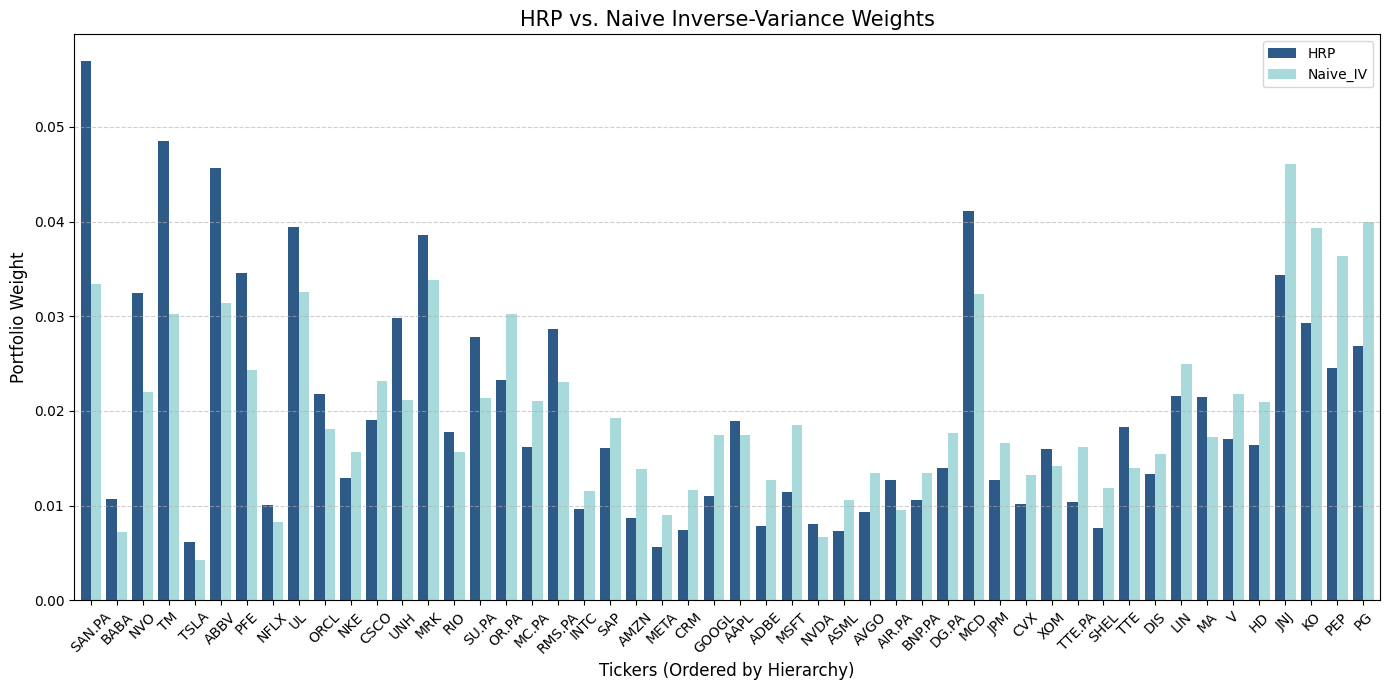

In [6]:
variances = np.diag(Sigma_ann)
inv_var = 1.0 / variances
naive_weights = pd.Series(inv_var / inv_var.sum(), index=hrp.tickers)

df_compare = pd.DataFrame({
    'HRP': weights,
    'Naive_IV': naive_weights
}).loc[weights.index]

ax = df_compare.plot(kind='bar', figsize=(14, 7), width=0.8, color=['#2E5A88', '#A8DADC'])

plt.title("HRP vs. Naive Inverse-Variance Weights", fontsize=15)
plt.ylabel("Portfolio Weight", fontsize=12)
plt.xlabel("Tickers (Ordered by Hierarchy)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
